# Element Creation Examples

In this notebook, we will show some examples for how to create elements as trees.
We will try to start with the thought process, and walk you through the code as we create the desired model.

In [1]:
import math
import numpy as np

from pathlib import PurePath

from coremaker.elements.box import BoxTree, ExcludeFrame, SplitBox, FrameBox, excludeframe_to_framebox
from coremaker.elements.assembly import singular_root_construction
from coremaker.elements.cylindrically_symmetric import AnnulusTree, ChunkedAnnulusTree, ChunkedCylinderTree, CylinderTree
from coremaker.materials.mixture import Mixture
from coremaker.materials.aluminium import al1050, al6061
from coremaker.materials.zirconium import zircalloy_4
from coremaker.materials.absorbers import hafnium, aic, b4c
from coremaker.materials.water import make_light_water
from coremaker.geometries import infiniteGeometry, FiniteCylinder, BareGeometry, Box as BoxGeometry, TriPrism
from coremaker.surfaces import Plane
from coremaker.transform import Transform
from coremaker.tree import Tree, Node
import matplotlib.pyplot as plt

# Case 1: MTR-style fuel

We start with the [specification of the OPAL reactor fuel](https://apo.ansto.gov.au/server/api/core/bitstreams/cbb082fd-3e09-44e5-b6e1-ea1e0a122a8f/content), found on pages 3-4.
We show just the figure from those pages, to remind readers what a fuel plate looks like in general.

![OPAL fuel](OPALfuel.png)

The full specification can be a bit tedious to read, but readers who care to do so may open that link and look at the tables while reading this example.

## Breaking the object down
Our first order of business is to deconstruct the object into its underlying components.
In this process, we want to say at each stage if things sit next to each other, or within one another. These correspond to inclusive and exclusive relations between the progeny nodes and their parent node. These concepts are covered in detail in the [Elements](elements.rst) section of the reference guide.

For our MTR fuel assembly, we start with the outmost shape, which is a 81.5mmx81.5mmx1045mm virtual box, or we could imagine it to be within an infinite pool of water instead.
We notice that we can split it into two regions, the `fuel plate` region and the so-called `end box` region.
These sit one atop the other, where the `end box` region is 145mm tall.
In a real setting, outside the end box we would have some free room between this leg and the grid, followed by the core grid material on top of which the fuel rods sit.
For our simplified model, we will assume that outside the `end box` we have light water, and in the `fuel plate` region anything outside the defined geometry is filled with light water at room temperature as well.

We can now break down each of these, and once one of them reaches its simplest shape, we will model it.

## The End Box
The end box is made up of a corner-cut 69mmx69mm square made up of aluminium-6061, where the corners are cut at 8mm isosceles right angle triangles, set **within** our end box region full of water.
**Within** this corner-cut square, we have a cylinder full of water with radius 60mm that is concentric with the square.

Thus, our `end box` tree would be:
    
```mermaid
flowchart TD

A[Infinite Water] -->|External| B[Cut Square]
B -->|External| C[Water Cylinder]
```

We could build that as is, which has the benefit that it follows the actual shape of the components in the model. However, this introduces some complication, since we need to model the cut corners. These make that box region more complicated and has more surfaces, which can sometimes degrade performance on some codes.
Therefore, we are faced with a choice. We can have this simple tree model where the middle node has a complex geometry, or we can build a more complex tree with simpler geometries. We could define this tree instead:

```mermaid
flowchart TD

A[Infinite Water] -->|External| B[69mm Square]
B -->|External| C1[4x 8mmx8mm Isosceles right angle triangles]
B -->|External| C2[Water Cylinder]
```

This construction has more components which will lead to more Cells in an OpenMC-adapted model, but each of which has less surfaces.
It also uses more established geometry types on our end, which increases how idiomatic the model is.

Since we are trying to teach the reader, we will show both options.

### Option 1: Smaller tree, complex geometry
Let's start by creating the materials we use. We have Al-6061 ready, so we just need the water.
We will use the tool for light water that we directly support.

In [2]:
water = make_light_water(25.)

Next, we need to make the infinite geometry and the inner cylinder.
The infiniteGeometry was already imported above, and since it is a singleton instance we don't need to do anything for it. Just the cylinder, then.
It is always best to create geometries with origin centers and leave any
shifts to the transformations in the tree, so we will take care of the z-shift of the end box with transformations.
Our system uses cm as the common unit of measurement, so the engineering-focused use of mm has to be converted.

In [3]:
endbox_cyl = FiniteCylinder(
    center=(0, 0, 0),  # Always prefer origin centers and leave translations to the transforms
    radius=60e-1, #60 mm in cm
    length=145e-1,
    axis=(0, 0, 1), # Z-axis
)

We can now make these into the simpler Nodes.

In [4]:
endbox_leg_flow = Node(geometry=endbox_cyl, mixture=water)
pool_node = Node(geometry=infiniteGeometry, mixture=water)

We can now build the complex geometry and its node

In [5]:
endbox_full = BoxGeometry(center=(0, 0, 0), dimensions=(69e-1, 69e-1, 145e-1))

From the figure above we can tell the sides of the corners and of the aluminium square, so we can find a formula for the distance between the corner and the center.

In [6]:
square_side = 69e-1  # cm
corner_side = 8e-1  # cm
z_height = 145e-1
b = corner_side*math.sqrt(2)
a = 1
c = (corner_side ** 2 - square_side ** 2) / 2
determinant = b ** 2 - 4*a*c
d = math.sqrt(2) * (-b + math.sqrt(determinant)) / (2*a)
triangle_volume = z_height * b ** 2 / 2
corners = [Plane(1, -1, 0, -d), Plane(1, 1, 0, -d), -Plane(1, -1, 0, d), -Plane(1, 1, 0, d)]
corners

[Plane<1.000e+00x + -1.000e+00y >= -6.100e+00>,
 Plane<1.000e+00x + 1.000e+00y >= -6.100e+00>,
 Plane<-1.000e+00x + 1.000e+00y >= -6.100e+00>,
 Plane<-1.000e+00x + -1.000e+00y >= -6.100e+00>]

To make sure we got this right, we can plot these lines.

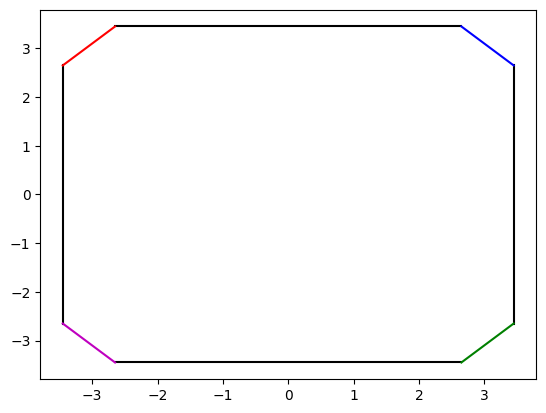

In [7]:
plt.figure()
bl = np.array([-square_side/2 + corner_side, -square_side/2])
br = np.array([square_side/2 - corner_side, -square_side/2])
tl = np.array([-square_side/2 + corner_side, square_side/2])
tr = np.array([square_side/2 - corner_side, square_side/2])
lb = np.array([-square_side/2, -square_side/2 + corner_side])
lt = np.array([-square_side/2, square_side/2 - corner_side])
rb = np.array([square_side/2, -square_side/2 + corner_side])
rt = np.array([square_side/2, square_side/2 - corner_side])

def p1(x): return x + d
def p2(x): return -x - d
def p3(x): return x - d
def p4(x): return -x + d

for v1, v2 in [(bl, br), (tl, tr), (lb, lt), (rb, rt)]:
    x, y = zip(v1, v2)
    plt.plot(x, y, 'k')

for v1, v2, f, c in [(tr, rt, p4, 'b'), (lt, tl, p1, 'r'), (lb, bl, p2, 'm'), (br, rb, p3, 'g')]:
    x = np.array([v1[0], v2[0]])
    y = f(x)
    plt.plot(x, y, c)

Which seems fine. So we can use the surfaces from the full box and from these corners to get a corner-cut box.

In [8]:
endbox_cut_corners = BareGeometry(list(endbox_full.surfaces) + corners, _volume=endbox_full.volume - 4 * triangle_volume)
endbox_box_node = Node(endbox_cut_corners, mixture=al6061)

Now we can build the Tree

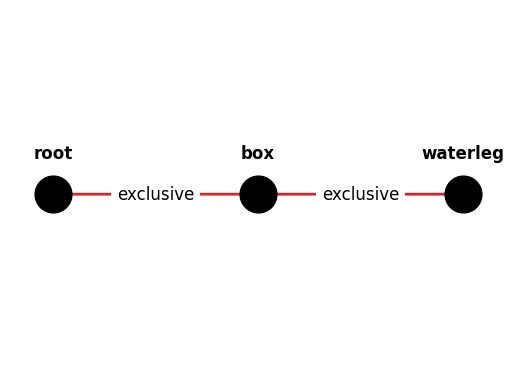

In [9]:
end_box = Tree()
end_box.nodes[PurePath("root")] = pool_node
end_box.nodes[PurePath("root/box")] = endbox_box_node
end_box.nodes[PurePath("root/box/waterleg")] = endbox_leg_flow
end_box.exclusive[PurePath("root")] = [(PurePath("root/box"), endbox_box_node)]
end_box.exclusive[PurePath("root/box")] = [(PurePath("root/box/waterleg"), endbox_leg_flow)]
end_box.plot()

### Option 2: Larger tree, simple geometry

There is a correct way to do this that takes slightly more work (we need to recompute some `Plane`s) and an incorrect way to do them that will likely bite you at some point, that takes less work and seems fine until it doesn't.

We'll start with the wrong way, and explain why it is wrong even though it succeeds.

#### The WRONG way to do things
<div class="alert alert-block alert-danger"><b>Warning:</b> This is not how you should do things, but shows you how you could mistakenly think to do them. Skip to the next subsection if you want to just see the right way to do things</div>
The only real change is that we use the full box geometry for the box node, and that we need the triangle nodes.

In [10]:
tr_tri = TriPrism((-corners[-1], -Plane(1, 0, 0, square_side/2), -Plane(0, 1, 0, square_side/2)), z_height, (square_side/2 - corner_side/2, square_side/2 - corner_side/2, 0))
tl_tri = TriPrism((-corners[0], Plane(1, 0, 0, -square_side/2), -Plane(0, 1, 0, square_side/2)), z_height, (-square_side/2 + corner_side/2, square_side/2 - corner_side/2, 0))
bl_tri = TriPrism((-corners[1], Plane(1, 0, 0, -square_side/2), Plane(0, 1, 0, -square_side/2)), z_height, (-square_side/2 + corner_side/2, -square_side/2 + corner_side/2, 0))
br_tri = TriPrism((-corners[2], -Plane(1, 0, 0, square_side/2), Plane(0, 1, 0, -square_side/2)), z_height, (square_side/2 - corner_side/2, -square_side/2 + corner_side/2, 0))
triangles = [tr_tri, tl_tri, bl_tri, br_tri]
triangle_nodes = [Node(tri, mixture=water) for tri in triangles]

endbox_full_node = Node(endbox_full, mixture=al6061)

And now we can assemble the Tree:

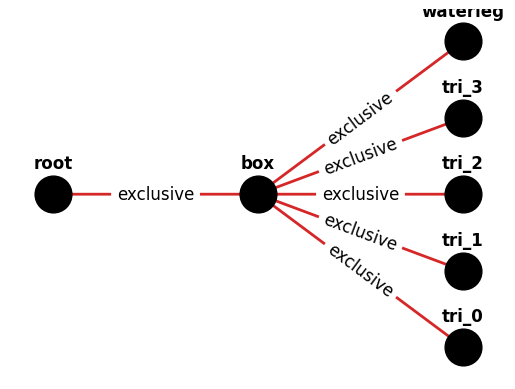

In [11]:
end_box_2 = Tree()
end_box_2.nodes[PurePath("root")] = pool_node
end_box_2.nodes[PurePath("root/box")] = endbox_full_node
end_box_2.exclusive[PurePath("root")] = [(PurePath("root/box"), endbox_full_node)]
for i, triangle in enumerate(triangle_nodes):
    end_box_2.nodes[PurePath(f"root/box/tri_{i}")] = triangle
end_box_2.exclusive[PurePath("root/box")] = [(PurePath(f"root/box/tri_{i}"), triangle) for i, triangle in enumerate(triangle_nodes)]
end_box_2.nodes[PurePath("root/box/waterleg")] = endbox_leg_flow
end_box_2.exclusive[PurePath("root/box")].extend([(PurePath("root/box/waterleg"), endbox_leg_flow)])
end_box_2.plot(label_offset=0.2)

If we don't have any computation errors, the planes should match our corners from before.

In [12]:
for _, c in end_box_2.named_components():
    surfs = c.geometry.surfaces
    planes = [s for s in surfs if isinstance(s, Plane) and s.a[0] != 0 and s.a[1] !=0]
    assert set(planes).issubset(set(corners) | set([-s for s in corners])), set(planes) - set(corners)

#### The RIGHT way to do this
<div style="background-color: #d4edda; color: #155724; padding: 15px; border: 1px solid #c3e6cb; border-radius: 5px;"><b>Note:</b> This is how you should do things. Don't do the other one.</div>
We need to create the `TriPrism`s such that they are centered, and put the translation on the transform in the nodes, instead.

In [13]:
side_offset = corner_side / 4  # You can do the math yourself, but I did :)
d = corner_side / 2  # You can do the math yourself, but I did :)
tr_tri = TriPrism((Plane(1, 1, 0, -d), -Plane(1, 0, 0, side_offset), -Plane(0, 1, 0, side_offset)), z_height, (0, 0, 0))
tl_tri = TriPrism((Plane(-1, 1, 0, -d), Plane(1, 0, 0, -side_offset), -Plane(0, 1, 0, side_offset)), z_height, (0, 0, 0))
bl_tri = TriPrism((Plane(-1, -1, 0, -d), Plane(1, 0, 0, -side_offset), Plane(0, 1, 0, -side_offset)), z_height, (0, 0, 0))
br_tri = TriPrism((Plane(1, -1, 0, -d), -Plane(1, 0, 0, side_offset), Plane(0, 1, 0, -side_offset)), z_height, (0, 0, 0))
triangles = [tr_tri, tl_tri, bl_tri, br_tri]
triangles

[TriPrism<sides:(Plane<1.000e+00x + 1.000e+00y >= -4.000e-01>, Plane<x <= 2.000e-01>, Plane<y <= 2.000e-01>), height:14.5, center:(0, 0, 0),
 TriPrism<sides:(Plane<-1.000e+00x + 1.000e+00y >= -4.000e-01>, Plane<x >= -2.000e-01>, Plane<y <= 2.000e-01>), height:14.5, center:(0, 0, 0),
 TriPrism<sides:(Plane<-1.000e+00x + -1.000e+00y >= -4.000e-01>, Plane<x >= -2.000e-01>, Plane<y >= -2.000e-01>), height:14.5, center:(0, 0, 0),
 TriPrism<sides:(Plane<1.000e+00x + -1.000e+00y >= -4.000e-01>, Plane<x <= 2.000e-01>, Plane<y >= -2.000e-01>), height:14.5, center:(0, 0, 0)]

The Planes seem to be in the right direction. We can now do the transforms.

In [14]:
off_center = square_side/2 - side_offset
transforms = [Transform(translation=(off_center, off_center, 0)),
              Transform(translation=(-off_center, off_center, 0)),
              Transform(translation=(-off_center, -off_center, 0)),
              Transform(translation=(off_center, -off_center, 0))
             ]
triangle_nodes = [Node(tri, transform=trans, mixture=water) for tri, trans in zip(triangles, transforms)]

The construction is actually the same.

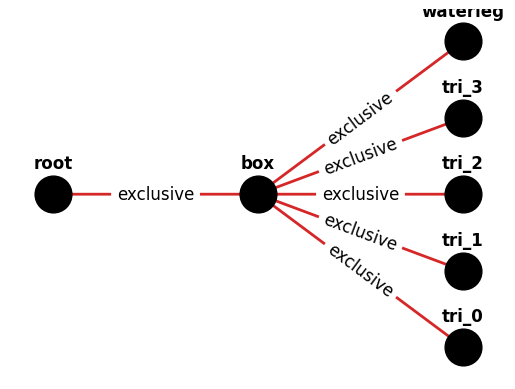

In [15]:
end_box_2 = Tree()
end_box_2.nodes[PurePath("root")] = pool_node
end_box_2.nodes[PurePath("root/box")] = endbox_full_node
end_box_2.exclusive[PurePath("root")] = [(PurePath("root/box"), endbox_full_node)]
for i, triangle in enumerate(triangle_nodes):
    end_box_2.nodes[PurePath(f"root/box/tri_{i}")] = triangle
end_box_2.exclusive[PurePath("root/box")] = [(PurePath(f"root/box/tri_{i}"), triangle) for i, triangle in enumerate(triangle_nodes)]
end_box_2.nodes[PurePath("root/box/waterleg")] = endbox_leg_flow
end_box_2.exclusive[PurePath("root/box")].extend([(PurePath("root/box/waterleg"), endbox_leg_flow)])
end_box_2.plot(label_offset=0.2)

If we got this right, the slanted planes should be the same as those we calculated before in Option 1:

In [16]:
corners

[Plane<1.000e+00x + -1.000e+00y >= -6.100e+00>,
 Plane<1.000e+00x + 1.000e+00y >= -6.100e+00>,
 Plane<-1.000e+00x + 1.000e+00y >= -6.100e+00>,
 Plane<-1.000e+00x + -1.000e+00y >= -6.100e+00>]

In [17]:
planes = set()
for _, c in end_box_2.named_components():
    surfs = c.geometry.surfaces
    planes |= {s for s in surfs if isinstance(s, Plane) and s.a[0] != 0 and s.a[1] !=0}
list(planes)

[Plane<1.000e+00x + -1.000e+00y >= 6.100e+00>,
 Plane<1.000e+00x + 1.000e+00y >= 6.100e+00>,
 Plane<-1.000e+00x + -1.000e+00y >= 6.100e+00>,
 Plane<-1.000e+00x + 1.000e+00y >= 6.100e+00>]

In [18]:
assert set(planes).issubset(set(corners) | set([-s for s in corners])), set(planes)

AssertionError: {Plane<1.000e+00x + -1.000e+00y >= 6.100e+00>, Plane<1.000e+00x + 1.000e+00y >= 6.100e+00>, Plane<-1.000e+00x + -1.000e+00y >= 6.100e+00>, Plane<-1.000e+00x + 1.000e+00y >= 6.100e+00>}

Moving on to the main part of the rod.

## The Active Region

The main region is built of 2 side plates which hold 21 plates in position. In standard and type 2 fuel, every other plate slot also holds a burnable absorber Cadmium wire.
We will cover the standard fuel in this example, you can work on doing the other ones on your own as an exercise, if you feel like it. It's a good mental exercise to think what would be different, even if you don't go about writing the model down.

In practice, the swaging process can somewhat reshape the exact geometry of how the wire is placed next to the fuel plate within the side plate. For example, the swaging process very well may squish them together such that no water gap is left, and instead the Aluminium comb-hairs are tilted and driven into the plate and the wire, leaving a larger water gap on the other side.
In our model, we will ignore this swaging process effect, because it is unclear exactly what form it will take. This is also how the problem is specified in the original paper.

Therefore, our side plates form a comb-shape. We can build the side plates either as a complex union geometry, or we can split it into multiple pieces, each of which holds just one plate.
The upside of making it one piece is that it is indeed just one piece in practice. However, that creates a region that is very geometrically complex, which may adversely affect transport solver runtimes. Having multiple, smaller cells may be better, but that also comes at the cost that there are more regions, which has its own costs in some cases.
There are no free lunches, though, if we want our model to be exact.
We could smear things together and approximate the problem, which you may want to do if the computational cost is prohibitive for you, but we are not going to run this model so we can afford to have more pieces with less approximations.
In this guide we will use the multiple-cell model for the side plate.

The shape is still too convoluted, because it is a complex comb shape. To make things simpler we will absorb the inactive region of the fuel plates into the model for the side plate. The side plate will thus externally be a box, which is made up of multiple boxes, each of which is made up of furthermore boxes.
The upside is that we get a very simple problem for the transport solver, but we pay the price that if someone wants to edit the material of an inactive region of a plate they must edit the pieces we took into the side plate region.
Oh well, there tradeoffs in life. ¯\\_(ツ)_/¯

The structure is therefore going to be of the form:

```mermaid
flowchart TB
A[Pool] -->|exclusive| B[Sideplate Virtual]
A -->|exclusive| C1[Plate Frame 1]
A -->|exclusive| C2[Plate Frame 2]
A -->|exclusive| More
A -->|exclusive| C3[Plate Frame 3]
subgraph SidePlate
B -->|inclusive| Al[Aluminium Block]
B -->|inclusive| TE1[Edge Tooth Left]
B -->|inclusive| S1[Plate Slot 1]
B -->|inclusive| T1[Tooth1]
B -->|inclusive| S2[Plate Slot 2]
B -->|inclusive| T2[Tooth2]
B -->|inclusive| Dots2[...]
B -->|inclusive| TE2[Edge Tooth Right]
S1 -->|inclusive| IA1[Inactive Plate 1]
S1 -->|inclusive| WS1[NoWire Aluminium 1]
S2 -->|inclusive| IA2[Inactive Plate 2]
S2 -->|inclusive| WS2[Wire Slot 2]
WS2 -->|exclusive| W2[Wire 2]
end

subgraph Plate 1
C1 --> M1[Plate 1 Meat]
end
subgraph Plate 2
C2 --> M2[Plate 2 Meat]
end
subgraph Plate 3
C3 --> M3[Plate 3 Meat]
end
subgraph More [More Plates]
Dots[...]
end

```